## **Northeastern SMILE Lab - Recognizing Faces in the Wild**

## Background

The SMILE Lab at Northeastern focuses on applied machine learning, social media analytics, human-computer interaction, and image/video understanding. This notebook applies that domain to the Families in the Wild (FIW) kinship-verification task.

Kinship recognition is challenging because available datasets may not fully represent global familial diversity, and facial similarity reflects both genetic and environmental factors. A learned image-pair model is therefore better suited than a fixed rule-based visual comparison.

## Objective

Using the provided competition data, this notebook predicts whether two face images depict related individuals. Throughout the notebook, `1` means related and `0` means unrelated.

## Notebook scope

This repository includes two related notebooks:

- `main.ipynb`: local/full workflow that downloads Kaggle data, builds and evaluates the scoring pipeline, and generates a Kaggle submission file.
- `kaggle.ipynb`: Kaggle Notebook adaptation that assumes the competition dataset is mounted under `/kaggle/input` and focuses on scoring-head training plus held-out evaluation.

## Roadmap

The workflow downloads and extracts the competition data, cleans labeled relationship rows, builds balanced image pairs with a family-aware split, embeds each face once with a frozen pretrained FaceNet encoder, trains a lightweight logistic-regression scoring head, evaluates a rank-blended kinship score on a held-out labeled test split, and finally scores the image pairs requested by the Kaggle sample submission.


## **Step 1**: Download the official Kaggle competition (FIW) data.

Before executing the following cells, review section 7 of the Kaggle competition rules: https://www.kaggle.com/competitions/recognizing-faces-in-the-wild/rules#7-competition-data.

Prerequisites for the local workflow:

- A Kaggle account with the FIW competition rules accepted.
- A configured Kaggle API token for local downloads.
- Local storage for the downloaded zip files and extracted `_provided-data`, `_train-faces`, and `_test` directories.

FIW data usage should cite the official FIW/RFIW papers:

- Joseph P. Robinson, Ming Shao, Hongfu Liu, Yue Wu, Timothy Gillis, and Yun Fu. "Visual Kinship Recognition of Families In the Wild." IEEE TPAMI Special Edition: Computational Face, 2018.
- Joseph P. Robinson, Ming Shao, Handong Zhao, Yue Wu, Timothy Gillis, and Yun Fu. "Recognizing Families In the Wild (RFIW): Data Challenge Workshop in conjunction with ACM MM 2017." ACM Multimedia Conference: Workshop on RFIW, 2017.
- Shuyang Wang, Joseph P. Robinson, and Yun Fu. "Kinship Verification on Families in the Wild with Marginalized Denoising Metric Learning." IEEE Automatic Face and Gesture Recognition, 2017.
- Joseph P. Robinson, Ming Shao, Yue Wu, and Yun Fu. "Families In the Wild (FIW): large-scale kinship image database and benchmarks." ACM Multimedia Conference, 2016.


In [1]:
download_path = '_provided-data' # Intermediate directories are excluded recursively via `.gitignore` (i.e., '_*/').
competition = 'recognizing-faces-in-the-wild' # Hosted here: https://www.kaggle.com/c/recognizing-faces-in-the-wild


In [2]:
import os
from kaggle.api.kaggle_api_extended import KaggleApi

zip_path = download_path + '/' + competition + '.zip'
if os.path.exists(zip_path):
    print('Data already downloaded: ' + zip_path)
else:
    os.makedirs(download_path, exist_ok=True)
    print('Downloading ' + competition + ' provided data into ' + download_path)
    api = KaggleApi()
    api.authenticate()
    api.competition_download_files(competition, path = download_path)

print('Step 1a complete: Kaggle data downloaded.')

Data already downloaded: _provided-data/recognizing-faces-in-the-wild.zip
Step 1a complete: Kaggle data downloaded.


In [3]:
import os
import zipfile

def unzip(zip_path):
    dest_dir = '_' + os.path.basename(zip_path)[:-4]
    if (not os.path.exists(dest_dir)):
        os.makedirs(dest_dir, exist_ok=True)
        print('Decompressing ' + zip_path + ' into ' + dest_dir)
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(dest_dir)
    print(dest_dir + '/')
    print(os.listdir(dest_dir)[:10])
    return dest_dir

print('Decompressing ' + competition + ' provided data:')
dataset_path = unzip(download_path + '/' + competition + '.zip')
training_image_path = unzip(dataset_path + '/train-faces.zip')
# test.zip holds the faceNNNNN.jpg images referenced by sample_submission.csv
# (test-faces.zip is a different, unreferenced image set from the competition's first launch).
testing_image_path = unzip(dataset_path + '/test.zip')

print('Step 1b complete: data decompressed.')

Decompressing recognizing-faces-in-the-wild provided data:
_recognizing-faces-in-the-wild/
['train-faces.zip', 'test-public-lists.zip', 'test-public-faces.zip', 'test.zip', 'train_relationships.csv', 'README.md', 'test-private-faces.zip', 'test-private-labels.zip', 'test-private-lists.zip', 'test-faces.zip']
_train-faces/
['F0658', 'F0667', 'F0031', 'F0693', 'F0499', 'F0835', 'F0036', 'F0204', 'F0660', 'F0803']
Decompressing _recognizing-faces-in-the-wild/test.zip into _test


_test/
['face05867.jpg', 'face05873.jpg', 'face01383.jpg', 'face03594.jpg', 'face02852.jpg', 'face05683.jpg', 'face00923.jpg', 'face00937.jpg', 'face05697.jpg', 'face04589.jpg']
Step 1b complete: data decompressed.


## **Step 2**: Load and clean the labeled dataset.

The `train_relationships.csv` file encodes ground-truth kinship relationships between pairs of people. The `p1` and `p2` columns use a `family/member` path format, which is later used to find each member's face images under the extracted training-image directory.

Rows are removed when either member does not have corresponding image data. This keeps later pair generation from failing on missing folders or images.


In [4]:
from collections import defaultdict
import glob
import pandas

relations_csv_path = dataset_path + '/train_relationships.csv'
print('Loading ' + relations_csv_path)
relations_df = pandas.read_csv(relations_csv_path, delimiter=',', header='infer')

# Create a dictionary to lookup image files for each member
family_dict = defaultdict(list)
for family in glob.glob(training_image_path + '*'):
    for member in glob.glob(family + '/*'):
        for image_path in glob.glob(member + '/*'):
            member = os.path.basename(member)
            image_path = os.path.basename(image_path)
            family_dict[member].append(image_path)

print('Images found for members of ' + str(len(family_dict.items())) + ' total families.')
for key, value in list(family_dict.items())[:5]:
    print(str(key) + ': ' + str(value) + ',')
    
# Remove entries which do not exist in the training set
print('The original ground truth relations data contains ' + str(len(relations_df)) + ' pairs.')
print(relations_df)

print('Checking for missing relation image data.')
fam_keys = family_dict.keys()
missing_relations_list = []
for index, row in relations_df.iterrows():
    split1 = row.p1.split('/')
    split2 = row.p2.split('/')
    p1fam = split1[0]
    p2fam = split2[0]
    if (p1fam not in fam_keys or p2fam not in fam_keys):
        missing_relations_list.append(index)
        continue
    p1member = split1[1]
    p2member = split2[1]
    if (p1member not in family_dict[p1fam] or p2member not in family_dict[p2fam]):
        missing_relations_list.append(index)
        continue
    images1 = os.listdir(training_image_path + '/' + p1fam + '/' + p1member)
    images2 = os.listdir(training_image_path + '/' + p2fam + '/' + p2member)
    if (len(images1) == 0 or len(images2) == 0):
        missing_relations_list.append(index)
        continue
if missing_relations_list:
    relations_df = relations_df.drop(missing_relations_list)
    print(str(len(missing_relations_list)) + ' pairs were removed due to missing data.')
    print(relations_df)
else:
    print('All relations were found to have valid image data.')

Loading _recognizing-faces-in-the-wild/train_relationships.csv
Images found for members of 786 total families.
F0658: ['MID6', 'MID1', 'MID7', 'MID2', 'MID5', 'MID3'],
F0667: ['MID1', 'MID2'],
F0031: ['MID1', 'MID2', 'MID5', 'MID4', 'MID3'],
F0693: ['MID1', 'MID2', 'MID4', 'MID3'],
F0499: ['MID1', 'MID2', 'MID3'],
The original ground truth relations data contains 3598 pairs.
              p1          p2
0     F0002/MID1  F0002/MID3
1     F0002/MID2  F0002/MID3
2     F0005/MID1  F0005/MID2
3     F0005/MID3  F0005/MID2
4     F0009/MID1  F0009/MID4
...          ...         ...
3593  F1000/MID5  F1000/MID8
3594  F1000/MID5  F1000/MID9
3595  F1000/MID6  F1000/MID9
3596  F1000/MID7  F1000/MID8
3597  F1000/MID7  F1000/MID9

[3598 rows x 2 columns]
Checking for missing relation image data.


1108 pairs were removed due to missing data.
              p1          p2
0     F0002/MID1  F0002/MID3
1     F0002/MID2  F0002/MID3
2     F0005/MID1  F0005/MID2
3     F0005/MID3  F0005/MID2
29    F0016/MID1  F0016/MID5
...          ...         ...
3571  F0998/MID5  F0998/MID3
3572  F0998/MID5  F0998/MID1
3573  F0998/MID6  F0998/MID1
3574  F0998/MID6  F0998/MID2
3575  F0998/MID6  F0998/MID3

[2490 rows x 2 columns]


## **Step 3**: Show a random selection of known related person pairs.

This visual check samples labeled relationships from the cleaned CSV and displays one image for each person in the pair.


              p1          p2
3009  F0825/MID1  F0825/MID3
2785  F0774/MID5  F0774/MID7
2667  F0754/MID3  F0754/MID4
Step 3 complete: sample relations displayed.


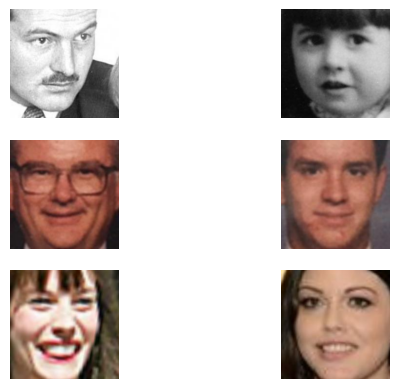

In [5]:
from PIL import Image
import matplotlib.pyplot as plt
from random import choice

SAMPLE_COUNT = 3
samples = relations_df.sample(SAMPLE_COUNT)
print(samples)

f, ax = plt.subplots(SAMPLE_COUNT, 2)
for a in ax.flat:
    a.axis('off')
i = 0
for member in samples.values:
    img1 = training_image_path + '/' + member[0] + '/' \
        + choice(os.listdir(training_image_path + '/' + member[0]))
    img2 = training_image_path + '/' + member[1] + '/'  \
        + choice(os.listdir(training_image_path + '/' + member[1]))
    rgb1 = Image.open(img1)
    rgb2 = Image.open(img2)
    ax[i][0].imshow(rgb1)
    ax[i][1].imshow(rgb2)
    i = i + 1

print('Step 3 complete: sample relations displayed.')

## **Step 4**: Split by family and generate balanced train, validation, and held-out test pairs.

Pairs are split by family so that members of the same family do not appear across training, validation, and held-out test splits. This reduces leakage: the model should be evaluated on families it did not see during training.

Positive pairs come from labeled kinship relationships. Negative pairs follow the sampling policy in `pair_sampling.py` (issue #10): a candidate pair is never the same member, never a known relation in either direction, and never two members of the same family — family membership implies potential kinship. The positive and negative pair sets are asserted disjoint.

In [6]:
import kinship

splits = kinship.build_pairs(relations_df, training_image_path, seed=42)
for name in ('train', 'val', 'test'):
    data = splits[name]
    positives = sum(1 for pair in data if pair[2] == 1.0)
    print(f'{name.capitalize():5s}: {len(data)} pairs ({positives} pos + {len(data) - positives} neg)')

print('Step 4 complete: family-aware splits generated.')

Train: 216018 pairs (108009 pos + 108009 neg)
Val  : 17362 pairs (8681 pos + 8681 neg)
Test : 23776 pairs (11888 pos + 11888 neg)
Step 4 complete: family-aware splits generated.


## **Step 5**: Embed faces and train the scoring head.

Earlier versions (v0.1–v0.6) trained a Siamese network end-to-end, most recently by fine-tuning the last two blocks of a pretrained FaceNet backbone with a new 512→128 projection head (test AUC 0.674). Measurement showed the *unmodified* frozen backbone outperforms that pipeline: the fine-tuning setup dropped the encoder's final L2 normalization, scrambled the pretrained embedding through a randomly initialized projection, let BatchNorm statistics drift on frozen layers, and used 112×112 inputs instead of the encoder's native 160×160.

The pipeline in `kinship.py` therefore keeps the pretrained `InceptionResnetV1` (VGGFace2) encoder frozen in eval mode at 160×160 and embeds each face image exactly once (cached to `_cache/embeddings-160.npz`, so re-runs skip this step). The only trained component is a logistic-regression head over the symmetric pair features `[|e1−e2|, e1⊙e2]`, early-stopped on validation AUC.

In [7]:
import os
import torch

# Device selection: prefer CUDA, then MPS (Apple Silicon GPU), then CPU
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

os.makedirs('_cache', exist_ok=True)
encoder = kinship.load_encoder(device)

unique_images = sorted({img for data in splits.values() for pair in data for img in pair[:2]})
print(f'Embedding {len(unique_images)} unique face images on {device}')
embeddings, failed = kinship.embed_images(
    encoder, unique_images, training_image_path, device=device,
    cache_path='_cache/embeddings-160.npz')
print(f'{len(embeddings)} embeddings ready ({len(failed)} images failed to load)')

# Pairs touching a failed image are dropped here, before any metric.
stacked = {name: kinship.stack_embeddings(embeddings, data)
           for name, data in splits.items()}

print('Step 5a complete: face embeddings ready.')

Embedding 9324 unique face images on cpu


9324 embeddings ready (0 images failed to load)


Step 5a complete: face embeddings ready.


In [8]:
e1_train, e2_train, y_train, _ = stacked['train']
e1_val, e2_val, y_val, _ = stacked['val']

head, best_val_auc = kinship.train_logreg_head(
    e1_train, e2_train, y_train, e1_val, e2_val, y_val)
torch.save(head.state_dict(), '_cache/logreg-head.pth')

print(f'Step 5b complete: scoring head trained (best val AUC {best_val_auc:.4f}) '
      'and saved to _cache/logreg-head.pth')

  epoch   1  val AUC 0.6274


  epoch  10  val AUC 0.6890


  epoch  20  val AUC 0.6975


  epoch  30  val AUC 0.7000


  epoch  40  val AUC 0.7006


  epoch  50  val AUC 0.7001


  epoch  60  val AUC 0.7009


  early stop at epoch 62 (best val AUC 0.7015 @ epoch 37)
Step 5b complete: scoring head trained (best val AUC 0.7015) and saved to _cache/logreg-head.pth


In [9]:
# Sanity check: related pairs should have higher cosine similarity than unrelated pairs.
cosine_train = kinship.cosine_scores(e1_train, e2_train)
mean_related = cosine_train[y_train == 1.0].mean()
mean_unrelated = cosine_train[y_train == 0.0].mean()
print(f'Mean cosine similarity (related pairs):   {mean_related:.4f}')
print(f'Mean cosine similarity (unrelated pairs): {mean_unrelated:.4f}')
if mean_related > mean_unrelated:
    print('PASS: Related pairs are more similar than unrelated pairs.')
else:
    print('FAIL: Related pairs are NOT more similar. The embeddings are not capturing kinship.')

Mean cosine similarity (related pairs):   0.1875
Mean cosine similarity (unrelated pairs): 0.0293
PASS: Related pairs are more similar than unrelated pairs.


## **Step 6**: Evaluate on the held-out labeled test split.

This evaluates the pipeline on the internal held-out labeled test split created from `train_relationships.csv`. This is separate from the unlabeled Kaggle competition submission image set (`test.zip`) used in the next step.

The final kinship score rank-blends two signals: raw cosine similarity between the frozen embeddings, and the trained head's logit. The blend weight is selected on the validation split and applied unchanged to the test split.

Blend weight (cosine share, selected on val): 0.7 (val AUC 0.7352)
Test AUC — cosine only:      0.7485
Test AUC — logreg head only: 0.7545
Test AUC — rank blend:       0.7645
Optimal threshold (Youden's J): 0.4887
Accuracy:  0.6969
Precision: 0.6954
Recall:    0.7008


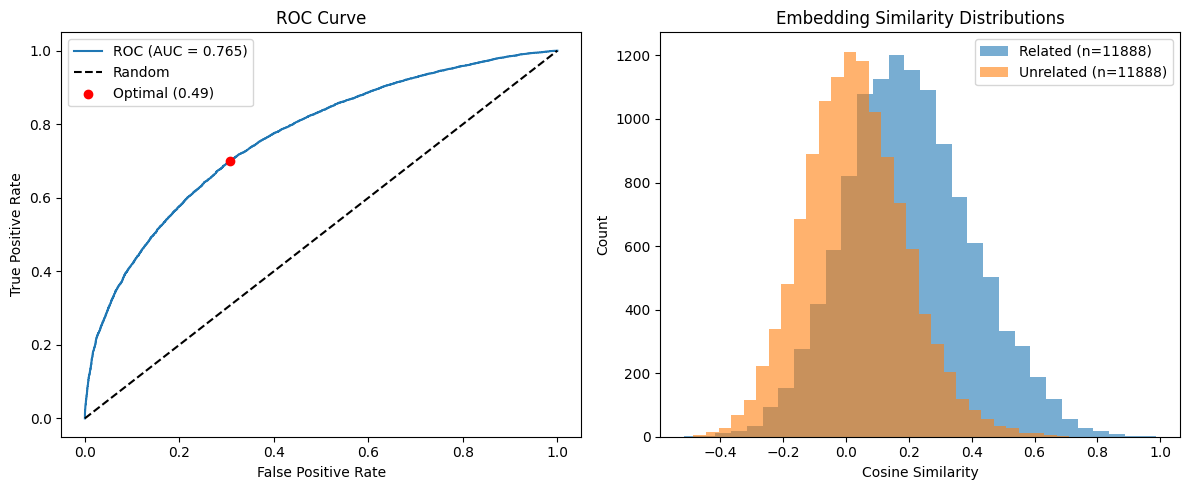

Step 6 complete: test metrics and plots generated.


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_auc_score, roc_curve, accuracy_score,
                             precision_score, recall_score)

e1_test, e2_test, y_test, _ = stacked['test']

cosine_val = kinship.cosine_scores(e1_val, e2_val)
logit_val = kinship.logit_scores(head, e1_val, e2_val)
cosine_test = kinship.cosine_scores(e1_test, e2_test)
logit_test = kinship.logit_scores(head, e1_test, e2_test)

blend_weight, blend_val_auc = kinship.select_blend_weight(cosine_val, logit_val, y_val)
print(f'Blend weight (cosine share, selected on val): {blend_weight:.1f} (val AUC {blend_val_auc:.4f})')

scores = kinship.rank_blend(cosine_test, logit_test, blend_weight)
auc = roc_auc_score(y_test, scores)
print(f'Test AUC — cosine only:      {roc_auc_score(y_test, cosine_test):.4f}')
print(f'Test AUC — logreg head only: {roc_auc_score(y_test, logit_test):.4f}')
print(f'Test AUC — rank blend:       {auc:.4f}')

# Optimal threshold via Youden's J statistic
fpr, tpr, thresholds = roc_curve(y_test, scores)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f"Optimal threshold (Youden's J): {optimal_threshold:.4f}")

predictions = (scores >= optimal_threshold).astype(float)
print(f'Accuracy:  {accuracy_score(y_test, predictions):.4f}')
print(f'Precision: {precision_score(y_test, predictions):.4f}')
print(f'Recall:    {recall_score(y_test, predictions):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr, tpr, label=f'ROC (AUC = {auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0].scatter(fpr[optimal_idx], tpr[optimal_idx], color='red', zorder=5,
                label=f'Optimal ({optimal_threshold:.2f})')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

axes[1].hist(cosine_test[y_test == 1.0], bins=30, alpha=0.6,
             label=f'Related (n={int(y_test.sum())})')
axes[1].hist(cosine_test[y_test == 0.0], bins=30, alpha=0.6,
             label=f'Unrelated (n={int((1 - y_test).sum())})')
axes[1].set_xlabel('Cosine Similarity')
axes[1].set_ylabel('Count')
axes[1].set_title('Embedding Similarity Distributions')
axes[1].legend()

plt.tight_layout()
plt.show()

print('Step 6 complete: test metrics and plots generated.')

## **Step 7**: Generate Kaggle submission predictions.

Kaggle submissions are evaluated on area under the ROC curve between the submitted `is_related` values and the hidden target labels. Only the image pairs listed in `sample_submission.csv` are scored (5,310 pairs), so exactly those pairs are submitted with their `img_pair` keys preserved verbatim — earlier versions scored all ~11.8M combinations of the 4,866 `test-faces.zip` images — a leftover image set from the competition's first launch that `sample_submission.csv` never references — under keys Kaggle never asked for and at ~2,200× the required work. The referenced images live in `test.zip`.

Each referenced test image is embedded once (cached to `_cache/test-embeddings-160.npz`); each requested pair is then scored with the same rank-blend and validation-selected weight as Step 6. The blended score ranks pairs for AUC evaluation; it is not calibrated as a true probability. Pairs touching an image that failed to load receive a neutral 0.5.

In [11]:
import numpy as np
import pandas
import torch

sample_df = pandas.read_csv(dataset_path + '/sample_submission.csv')
requested_pairs = [key.split('-') for key in sample_df['img_pair']]
assert all(len(pair) == 2 for pair in requested_pairs)
print(f'{len(requested_pairs)} requested pairs from sample_submission.csv')

submission_images = sorted({img for pair in requested_pairs for img in pair})
print(f'Embedding {len(submission_images)} unique test images on {device}')
test_embeddings, test_failed = kinship.embed_images(
    encoder, submission_images, testing_image_path, device=device,
    cache_path='_cache/test-embeddings-160.npz')

valid = [i for i, (img1, img2) in enumerate(requested_pairs)
         if img1 in test_embeddings and img2 in test_embeddings]
e1 = torch.from_numpy(np.stack([test_embeddings[requested_pairs[i][0]] for i in valid]))
e2 = torch.from_numpy(np.stack([test_embeddings[requested_pairs[i][1]] for i in valid]))

blended = kinship.rank_blend(kinship.cosine_scores(e1, e2),
                             kinship.logit_scores(head, e1, e2),
                             blend_weight)
submission_scores = np.full(len(requested_pairs), 0.5)
submission_scores[valid] = blended

sample_df['is_related'] = [format(score, '.6f') for score in submission_scores]
sample_df.to_csv('submission.csv', index=False)
print(f'Step 7 complete: {len(sample_df)} pair predictions written to submission.csv '
      f'({len(requested_pairs) - len(valid)} pairs defaulted to 0.5).')

5310 requested pairs from sample_submission.csv
Embedding 6129 unique test images on cpu
  embedded 0/6129 new images


  embedded 1024/6129 new images


  embedded 2048/6129 new images


  embedded 3072/6129 new images


  embedded 4096/6129 new images


  embedded 5120/6129 new images


Step 7 complete: 5310 pair predictions written to submission.csv (0 pairs defaulted to 0.5).
